In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import torch
import numpy as np
from nnfabrik.builder import get_data, get_trainer

from model import stacked_core_full_gauss_readout
from trainer import standard_trainer
from sensorium.utility.scores import get_correlations

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from autoencoder import VAE

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]


dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
    "shifter": True, 
    "autoencoder": None,
}

trainer_config = {
    'max_iter': 200,
    'verbose': False,
    'lr_decay_steps': 4,
    'avg_loss': False,
    'lr_init': 0.009,
    'device': device, 
}

In [4]:
model_seeds = [0, 1, 2]

In [5]:
def train_autoenc(autoencoder, features):
    criterion = torch.nn.MSELoss(reduction='sum')
    optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.3, patience=100)

    epochs = int(1e15)
    min_lr = 1e-5

    for epoch in range(epochs):
        recon, mu, logvar = autoencoder(features, return_params=True)
        recon_loss = criterion(features, recon)
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + 100 * kld_loss

        optim.zero_grad()
        loss.backward()
        optim.step()
        scheduler.step(loss.item())
        if epoch % 100 == 0:
            lr = optim.param_groups[0]['lr']
            if lr < min_lr:
                break

            print(kld_loss.item())
            print(lr, loss.item())

In [6]:
# Autoencoder configs for different latent dims that result in less than 1% performance drop
autoencoder_configs = [
    { 'latent_dim': 32, 'hidden_dims': 512, 'hidden_layers': 3, }, 
    { 'latent_dim': 16, 'hidden_dims': 512, 'hidden_layers': 5, }, 
    { 'latent_dim': 8, 'hidden_dims': 512, 'hidden_layers': 7, }, 
    { 'latent_dim': 4, 'hidden_dims': 1024, 'hidden_layers': 7, }, 
]

In [11]:
# Train all autoencoders for each model

all_features = []

for model_seed in model_seeds:
    checkpoint = torch.load(f'checkpoints/base/model_weights{model_seed}.pth')

    # Extract features from all mice
    features = []
    for data_key in data_keys:
        features_single_mouse = checkpoint[f'readout.{data_key}._features']
        features_single_mouse = features_single_mouse.squeeze().permute(1, 0).detach()
        features.append(features_single_mouse)
    features = torch.cat(features)

    feature_dict = {
        'base': features.detach().cpu().numpy()
    }

    for autoencoder_config in autoencoder_configs:
        autoencoder = VAE(
            64, batch_norm=True, nonlinearity='GELU', **autoencoder_config
        )
        autoencoder.load_state_dict(
            torch.load(f'checkpoints/autoencoder/model_weights{model_seed}_{autoencoder_config['latent_dim']}.pth')
        )
        autoencoder.to(device)
        #train_autoenc(autoencoder, features)
        #torch.save(
        #    autoencoder.state_dict(), 
        #    f'checkpoints/autoencoder/model_weights{model_seed}_{autoencoder_config['latent_dim']}.pth'
        #)

        latent_features = autoencoder.encode(features)[0].detach().cpu().numpy()
        feature_dict[autoencoder_config['latent_dim']] = latent_features

    all_features.append(feature_dict)

    with open('all_features.pkl', 'wb') as f:
        pickle.dump(all_features, f)

In [12]:
with open('all_features.pkl', 'rb') as f:
    all_features = pickle.load(f)

In [9]:
# Performance comparison 

for model_seed in model_seeds:
    checkpoint = torch.load(f'checkpoints/base/model_weights{model_seed}.pth')
    model = stacked_core_full_gauss_readout(dataloaders, model_seed, **model_config)
    model.load_state_dict(checkpoint)
    model.eval()
    
    validation_score = get_correlations(
        model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
    )
    print('base', validation_score)

    for autoencoder_config in autoencoder_configs:
        autoencoder = VAE(
            64, batch_norm=True, nonlinearity='GELU', **autoencoder_config
        )

        checkpoint = torch.load(f'checkpoints/autoencoder/model_weights{model_seed}_{autoencoder_config['latent_dim']}.pth')
        autoencoder.load_state_dict(checkpoint)
        autoencoder.eval()

        for data_key in data_keys:
            model.readout[data_key].autoencoder = autoencoder
    
        validation_score = get_correlations(
            model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
        )
        print(autoencoder_config['latent_dim'], validation_score)
    print()

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


base 0.38690987
32 0.3620155
16 0.37047133
8 0.35331523
4 0.16183762

base 0.3818726
32 0.3640795
16 0.36618188
8 0.21369076
4 0.2521057

base 0.37960163
32 0.36058873
16 0.36068252
8 0.24061352
4 0.19624309



In [19]:
def cluster(points, n_cluster, seed):
    kmeans = KMeans(n_clusters=n_cluster, random_state=seed)
    labels = kmeans.fit_predict(points)
    
    return labels

In [20]:
# For each model type and num clusters, cluster the features from 3 different seeds and compute ARI 

n_clusters = np.unique(np.geomspace(2, 100, dtype=int, num=30))

ari_dict = {}
label_dict = {}

for model_type in all_features[0].keys():
    ari_curve = []
    cluster_labels = []
    for n_cluster in n_clusters:
        labels = []
        # Loops through the 3 different seeds
        for feature_dict in all_features:
            features = feature_dict[model_type]
            labels.append(cluster(features, n_cluster, 0))  # Fix clustering seed

        ari = (
            adjusted_rand_score(labels[0], labels[1])
            + adjusted_rand_score(labels[0], labels[2])
            + adjusted_rand_score(labels[1], labels[2])
        ) / 3

        ari_curve.append(ari)
        cluster_labels.append(labels)

    ari_dict[model_type] = ari_curve
    label_dict[model_type] = cluster_labels

with open('labels.pkl', 'wb') as f:
    pickle.dump(label_dict, f)

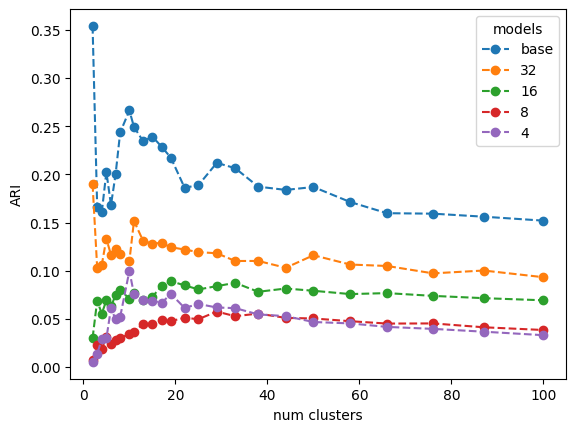

In [21]:
for model_type, ari_curve in ari_dict.items():
    plt.plot(n_clusters, ari_curve, ls='--', marker='o', label=model_type)

plt.xlabel('num clusters')
plt.ylabel('ARI')
plt.legend(title='models')
plt.show()

In [23]:
# t-sne

from sklearn.manifold import TSNE



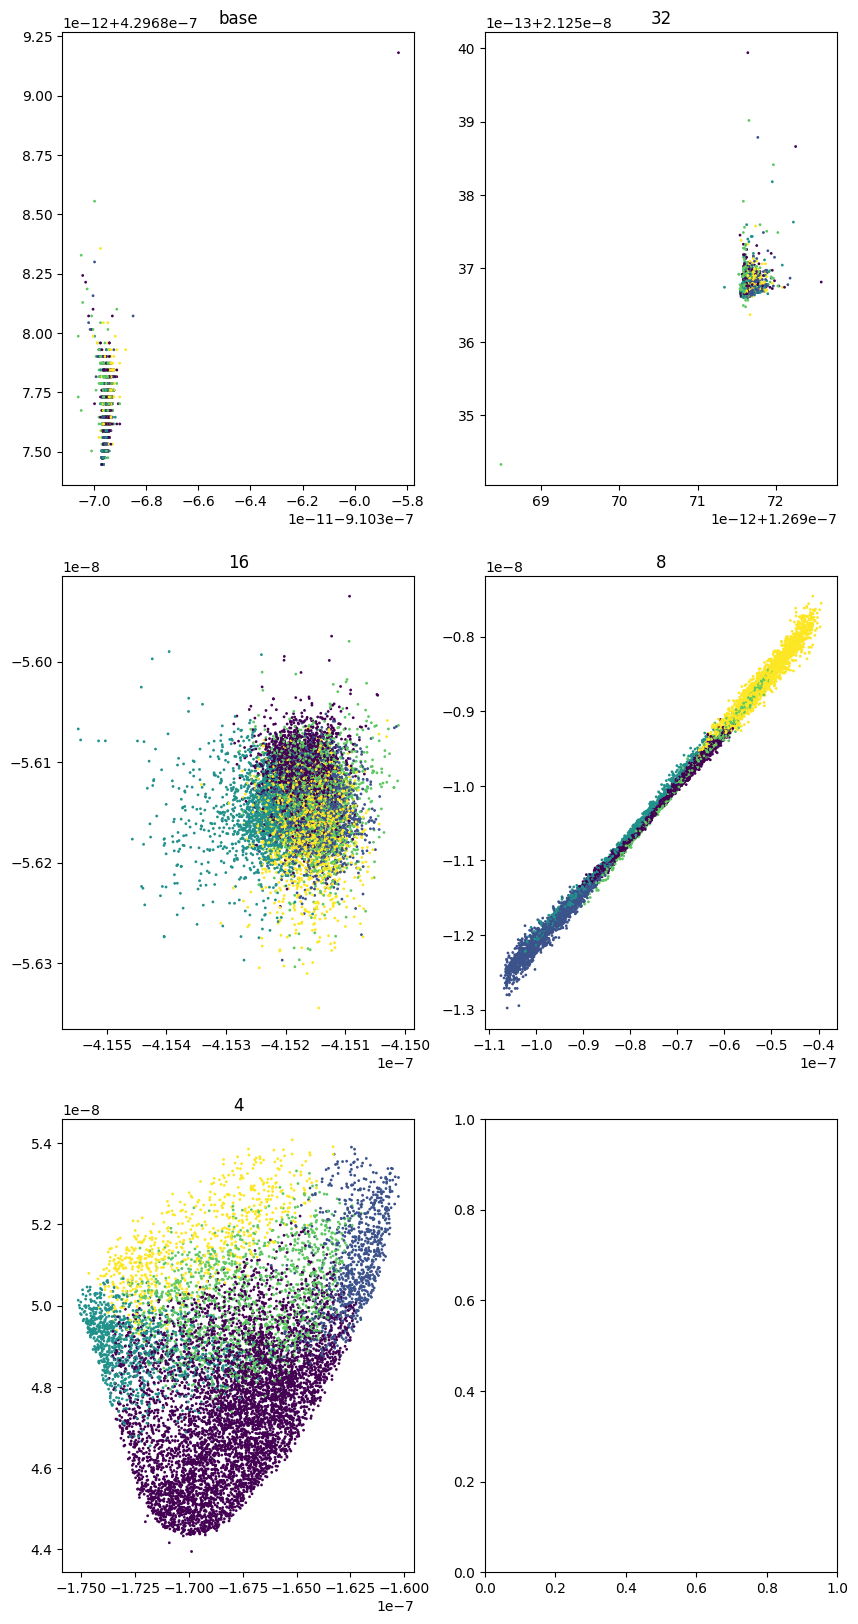

In [ ]:
seed_nr = 1
model_types = all_features[seed_nr].keys()
fig, axs = plt.subplots(3, 2, figsize=(10, 20))
idcs = np.random.permutation(all_features[seed_nr]['base'].shape[0])[:10000]

for i, model_type in enumerate(model_types):
    X = all_features[seed_nr][model_type][idcs]
    N = X.shape[0]
    tsne = TSNE(
        perplexity=N / 100,
        learning_rate=1,
        early_exaggeration=N / 10,
        random_state=0, 
    )
    X_tsne = tsne.fit_transform(X)
    
    labels = np.array(label_dict[model_type])[:, seed_nr, idcs]
    axs[i // 2][i % 2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels[3], s=1)
    axs[i // 2][i % 2].set_title(model_type)